In [72]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score,davies_bouldin_score



# 1. Data Exploration & Preprocessing

In [101]:
df = pd.read_csv("..\data\single_genre_artists.csv")
original_df = df.copy()
print("Shape:", df.shape)
print("\nColumns :\n", df.columns)
print("\nColumn dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (95837, 23)

Columns :
 Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists'],
      dtype='str')

Column dtypes:
 id_songs                  str
name_song                 str
popularity_songs        int64
duration_ms             int64
explicit                int64
id_artists                str
release_date              str
danceability          float64
energy                float64
key                     int64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature          int64
followers 

In [ ]:
df.head()

In [99]:
df.tail()

,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,...,valence,tempo,time_signature,followers,popularity_artists,release_year,cluster,Cluster_Name,PC1,PC2
95832,70,174800,0,0.674,0.5680,1,-6.356,1,0.0408,0.116,...,0.640,166.107,4,16057.0,56,2019,1,Energetic Party & Pop Tracks,1.574696,-0.176296
95833,50,265846,0,0.528,0.6730,4,-3.639,1,0.0314,0.143,...,0.297,130.066,4,929.0,36,2020,1,Energetic Party & Pop Tracks,1.398899,-1.558286
95834,67,82500,0,0.609,0.0172,8,-28.573,1,0.1180,0.996,...,0.890,68.619,4,23.0,52,2020,0,Chill Acoustic & Instrumental,-3.647104,1.247898
95835,66,185250,0,0.562,0.0331,1,-25.551,1,0.1030,0.996,...,0.386,63.696,3,91.0,55,2020,0,Chill Acoustic & Instrumental,-4.122440,-0.192432
95836,50,258267,0,0.560,0.5180,0,-7.471,0,0.0292,0.785,...,0.211,131.896,4,896.0,38,2020,0,Chill Acoustic & Instrumental,-0.346049,-1.472785


In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df['release_date'].value_counts()

In [3]:
df['release_year'] = (
    df['release_date']
    .astype(str)
    .str.extract(r'(\d{4})')[0]
    .astype('Int64')   
)

In [43]:
df[['release_date', 'release_year']].head(10)

,release_date,release_year
0,1922,1922
1,1922,1922
2,1922,1922
3,1924,1924
4,1924,1924
5,1924,1924
6,1925,1925
7,1925,1925
8,1925,1925
9,1926,1926


In [4]:
df.drop(columns=['name_artists',
                 'name_song',
                 'id_songs',
                 'id_artists',
                 'release_date','genres'],
        inplace=True)

# 2. Feature Selection

### Visualize the Distribution of Key Features

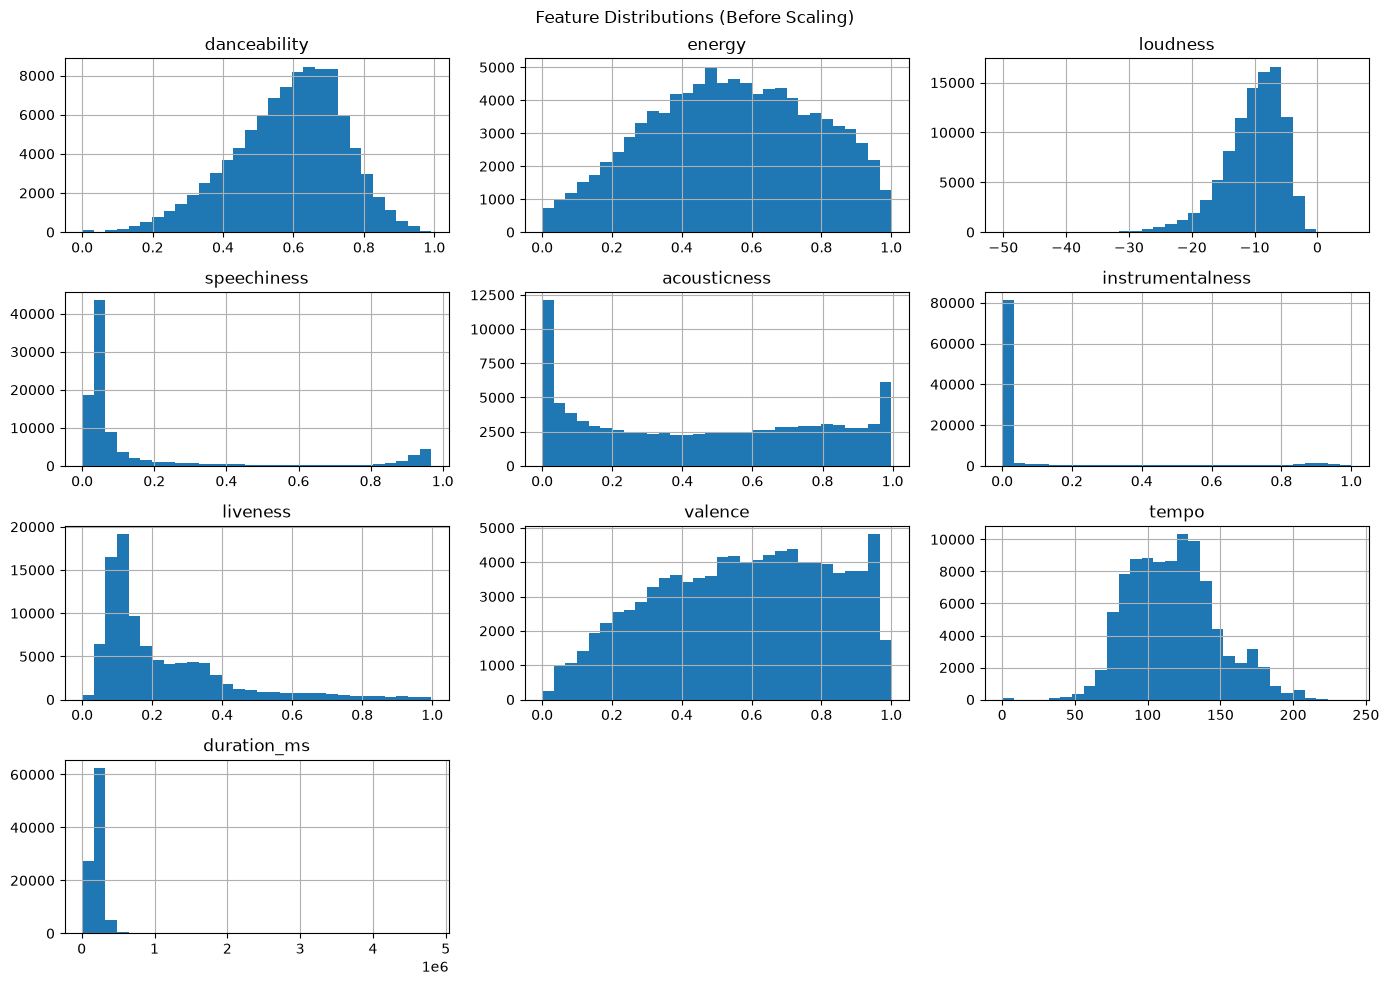

In [5]:
key_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

key_features_df = df[key_features] 
key_features_df.hist(figsize=(14, 10), bins=30)
plt.suptitle("Feature Distributions (Before Scaling)")
plt.tight_layout()
# plt.savefig("feature_distributions.png")
plt.show()
plt.close()


<Axes: >

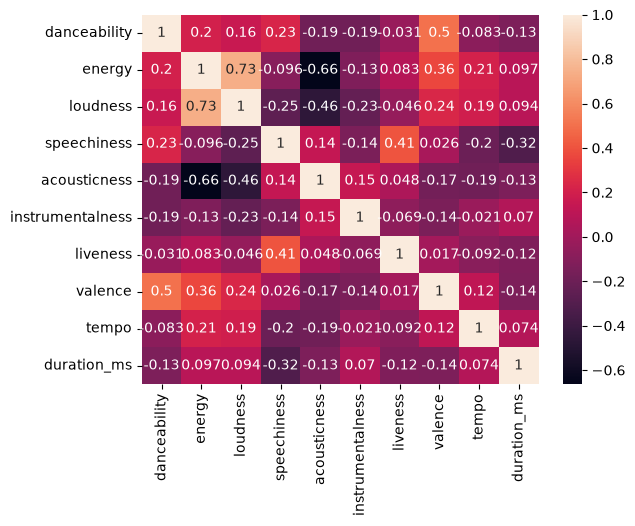

In [100]:
sns.heatmap(
    df[key_features].corr(),
    annot=True
)

### Outliers

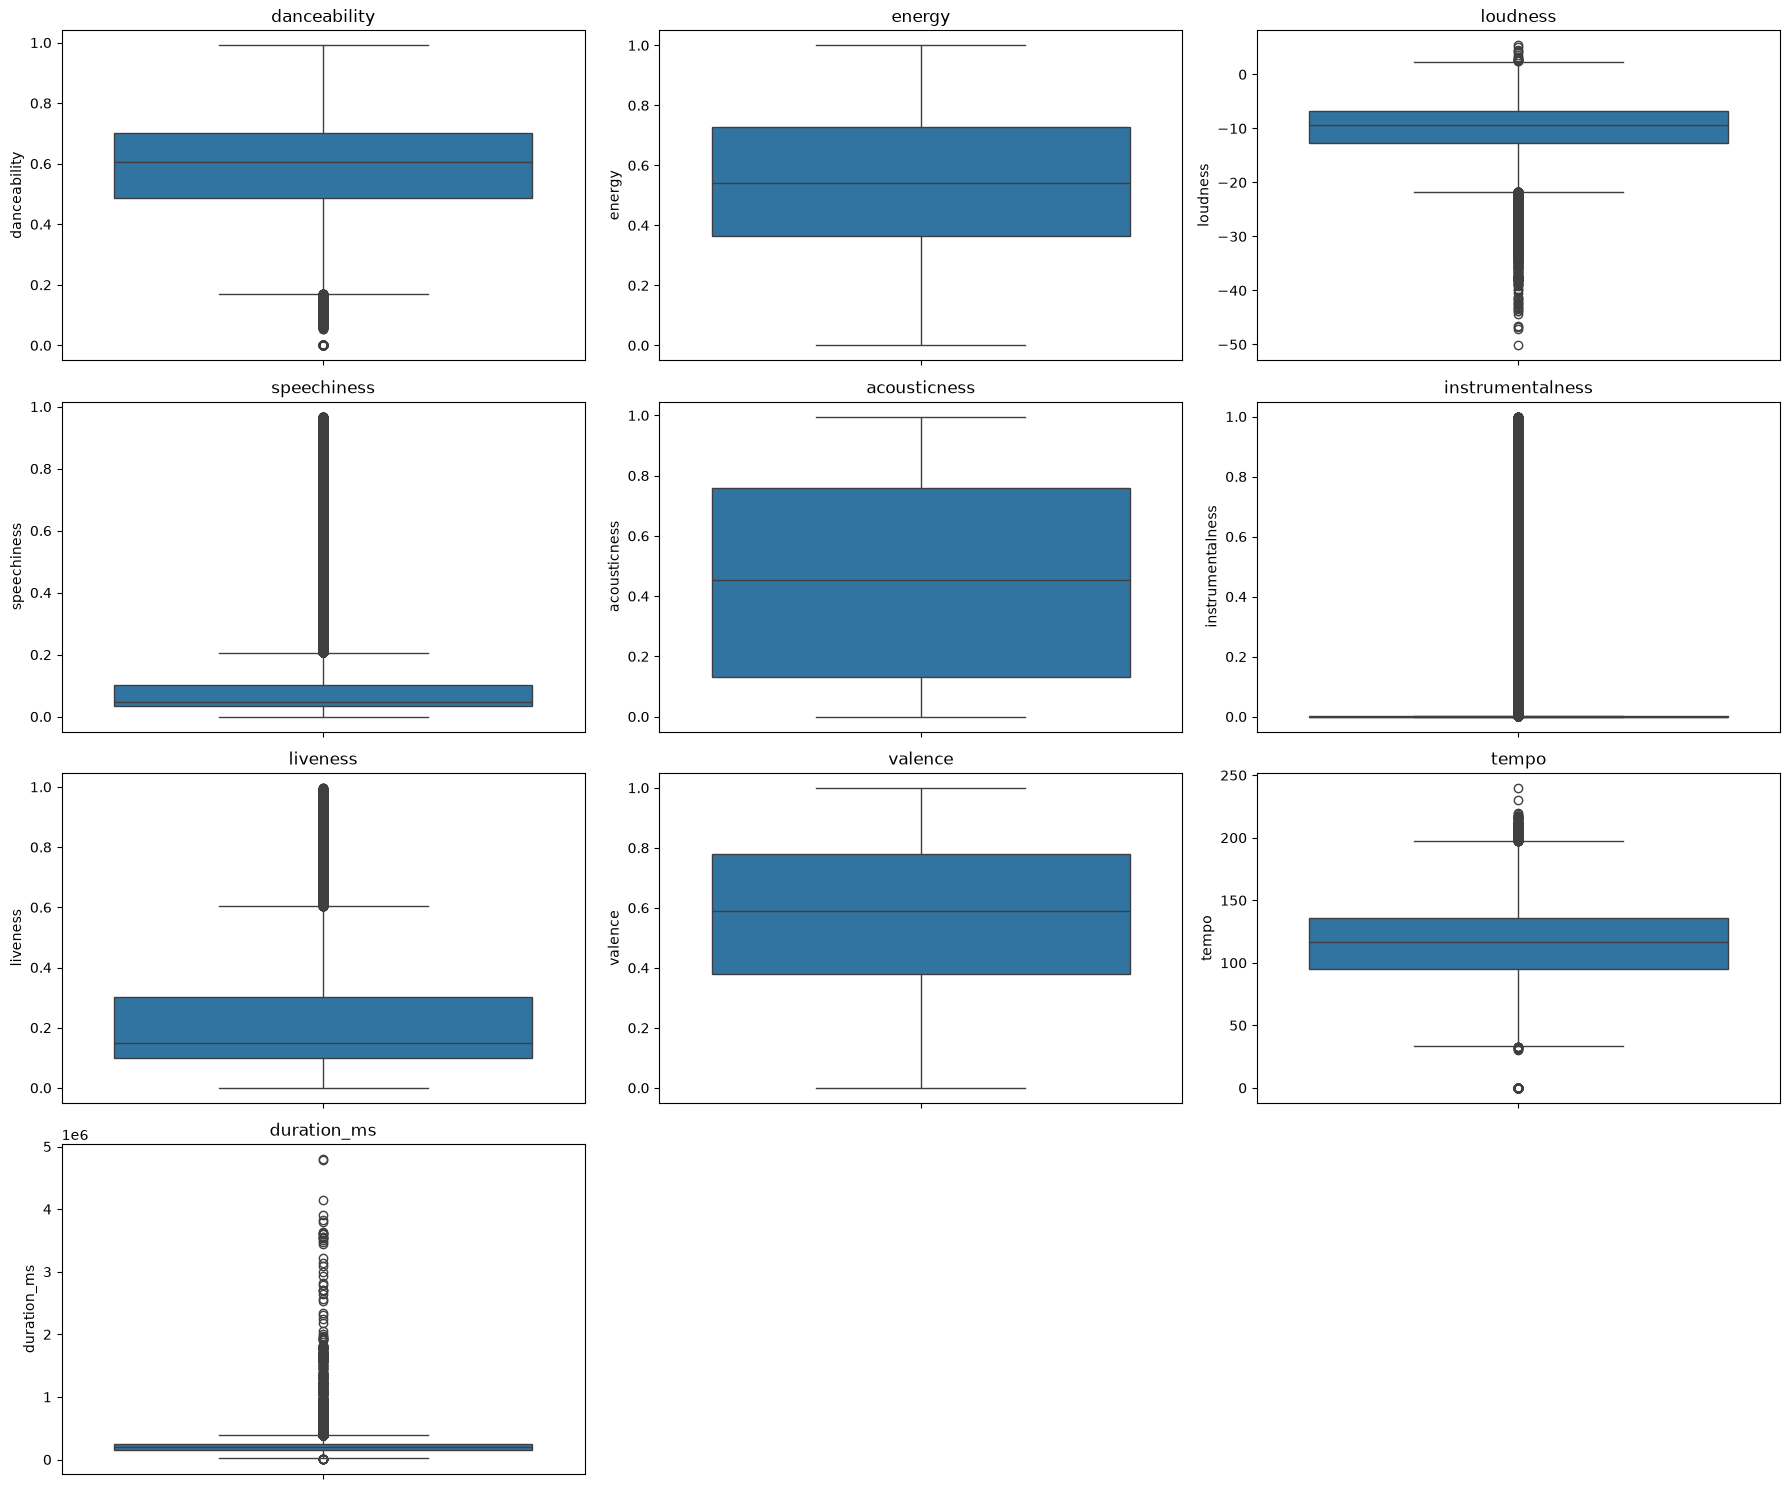

In [56]:
plt.figure(figsize=(18,15))

for i, feature in enumerate(key_features, 1):
    plt.subplot(4,3,i)
    sns.boxplot(y=key_features_df[feature])
    plt.title(feature)

plt.tight_layout()
plt.show()

In [6]:
cleaned_dataframe = key_features_df.copy()

def cap_outliers_iqr(series, factor=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - factor * iqr, q3 + factor * iqr
    return series.clip(lower=lower, upper=upper)
 
for col in key_features:
    cleaned_dataframe[col] = cap_outliers_iqr(cleaned_dataframe[col])
    print(cleaned_dataframe[col])



0        0.563
1        0.427
2        0.511
3        0.676
4        0.650
         ...  
95832    0.674
95833    0.528
95834    0.609
95835    0.562
95836    0.560
Name: danceability, Length: 95837, dtype: float64
0        0.1840
1        0.1800
2        0.2060
3        0.4670
4        0.2980
          ...  
95832    0.5680
95833    0.6730
95834    0.0172
95835    0.0331
95836    0.5180
Name: energy, Length: 95837, dtype: float64
0       -13.7570
1       -15.3750
2       -15.5140
3       -12.3930
4       -13.8060
          ...   
95832    -6.3560
95833    -3.6390
95834   -21.7695
95835   -21.7695
95836    -7.4710
Name: loudness, Length: 95837, dtype: float64
0        0.0512
1        0.0670
2        0.0592
3        0.1650
4        0.1380
          ...  
95832    0.0408
95833    0.0314
95834    0.1180
95835    0.1030
95836    0.0292
Name: speechiness, Length: 95837, dtype: float64
0        0.993
1        0.989
2        0.995
3        0.991
4        0.991
         ...  
95832    0.116
95

### After outlier capping

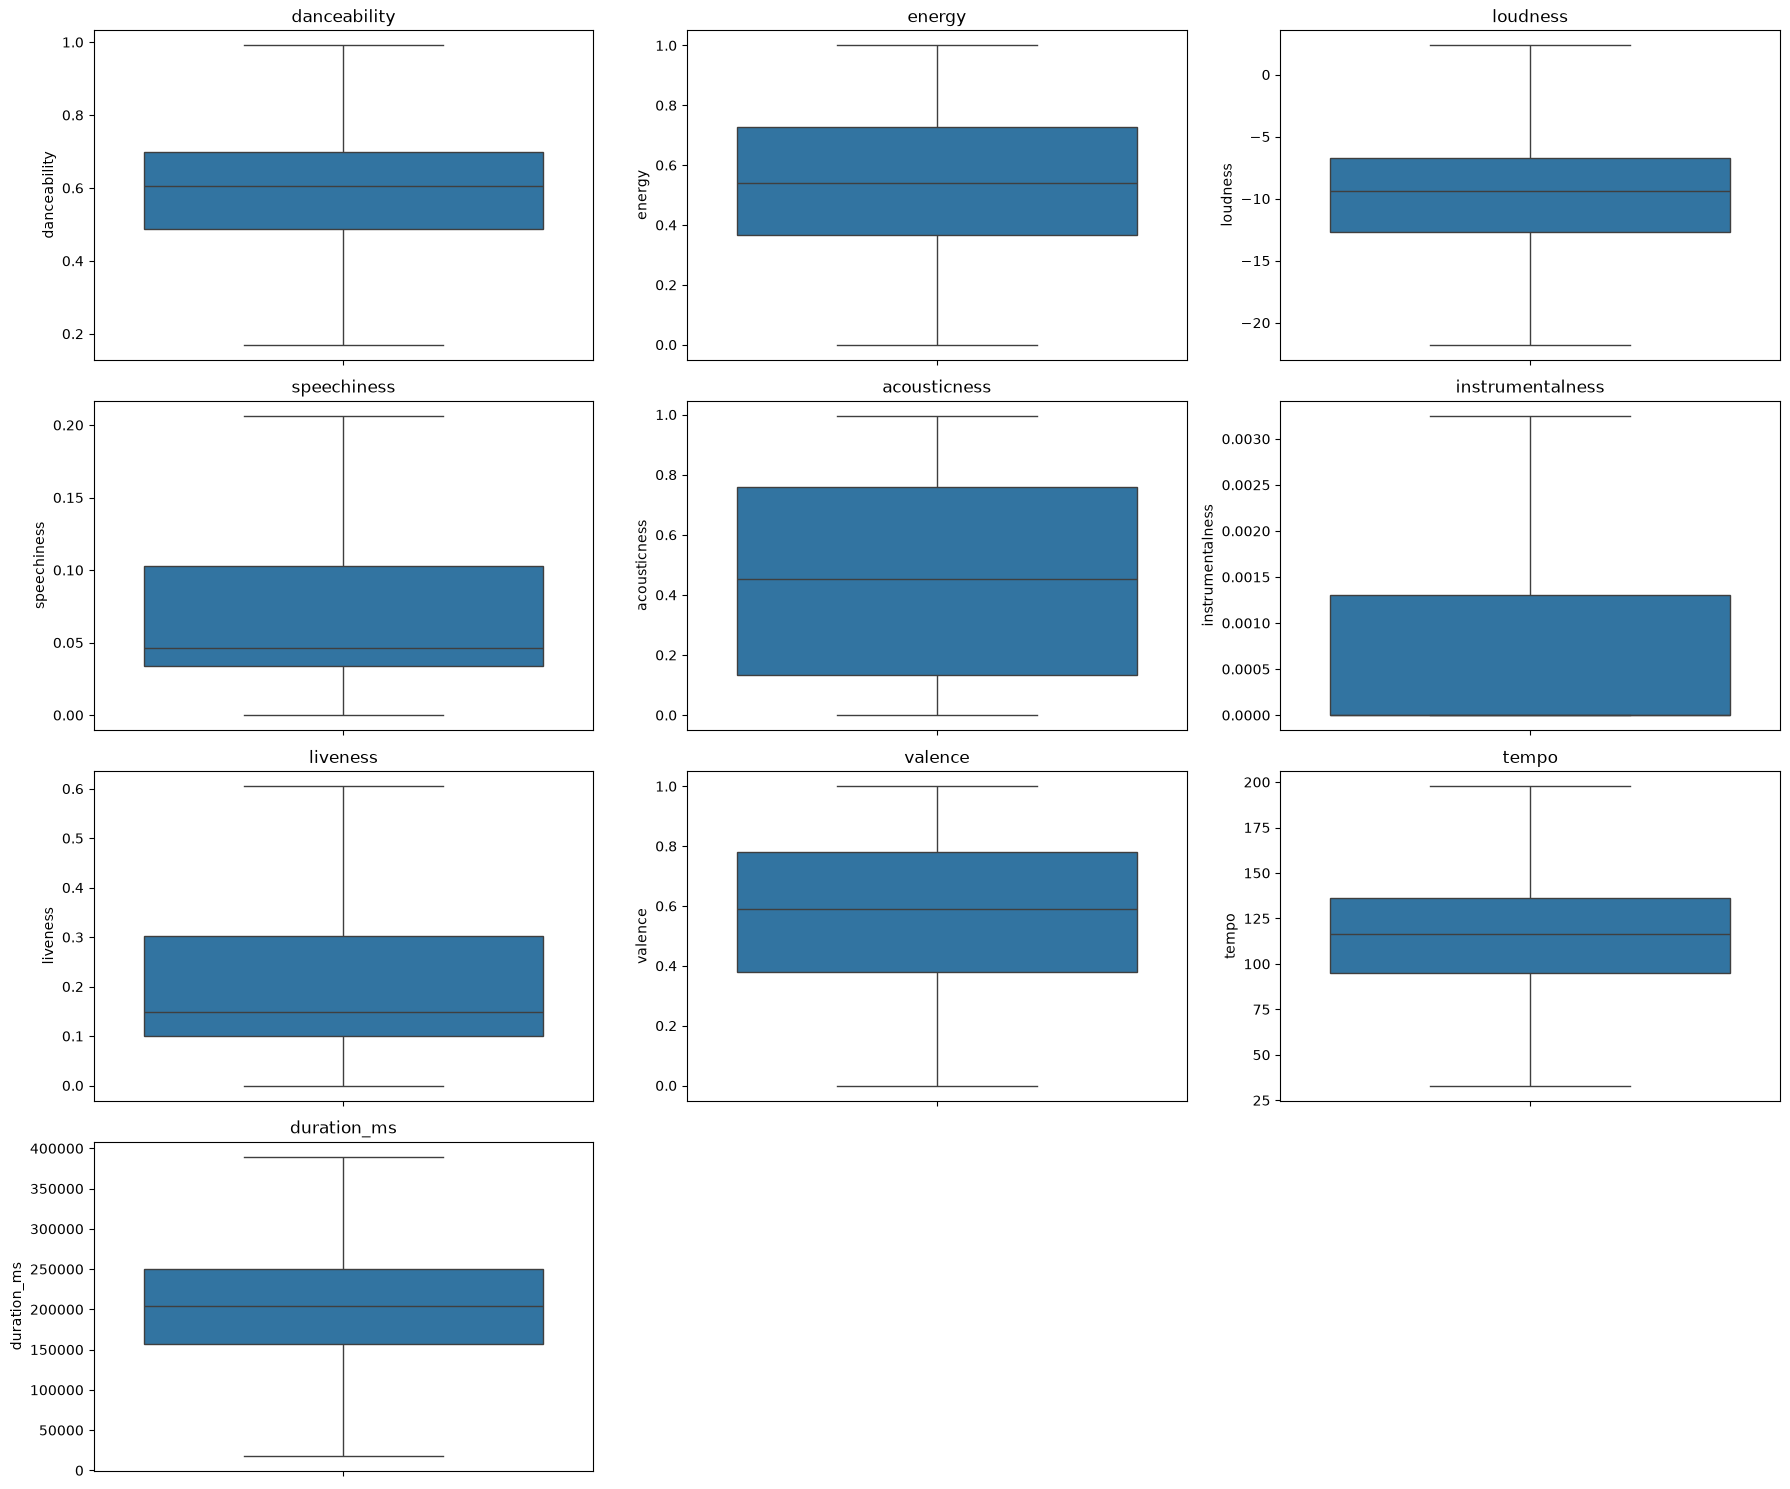

In [57]:
plt.figure(figsize=(18,15))

for i, feature in enumerate(key_features, 1):
    plt.subplot(4,3,i)
    sns.boxplot(y=cleaned_dataframe[feature])
    plt.title(feature)

plt.tight_layout()
plt.show()

### Data Normalization - Standard Scaler

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(cleaned_dataframe)
X_scaled = pd.DataFrame(X_scaled, columns=key_features)
# X_scaled


# After Scaling
print(X_scaled)
print(X_scaled['danceability'].min())
print(X_scaled['danceability'].max())

       danceability    energy  loudness  speechiness  acousticness  \
0         -0.157442 -1.511128 -0.826909    -0.443434      1.616187   
1         -1.039651 -1.528056 -1.189864    -0.204434      1.604081   
2         -0.494758 -1.418027 -1.221045    -0.322421      1.622240   
3          0.575570 -0.313510 -0.520933     1.277968      1.610134   
4          0.406912 -1.028695 -0.837901     0.869551      1.610134   
...             ...       ...       ...          ...           ...   
95832      0.562596  0.113908  0.833305    -0.600750     -1.038056   
95833     -0.384482  0.558254  1.442791    -0.742939     -0.956340   
95834      0.140952 -2.217003 -2.624297     0.567020      1.625267   
95835     -0.163929 -2.149717 -2.624297     0.340122      1.625267   
95836     -0.176903 -0.097685  0.583185    -0.776218      0.986675   

       instrumentalness  liveness   valence     tempo  duration_ms  
0             -0.603133  0.696794  0.321287  0.519910    -0.540644  
1             -0.6146

# 3. Dimensionality Reduction

In [ ]:

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (95837, 10)
PCA shape: (95837, 2)


In [9]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio:
[0.26686904 0.20874828]
Total explained variance: 0.47561732049124816


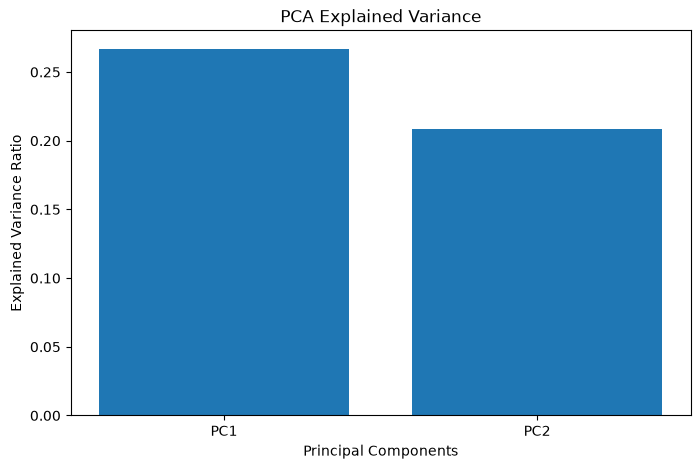

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    ['PC1', 'PC2'],
    pca.explained_variance_ratio_
)

plt.ylabel("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.title("PCA Explained Variance")

plt.show()

In [62]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df.head()

,PC1,PC2
0,-1.840106,0.507093
1,-2.718534,-0.442733
2,-2.651019,0.543211
3,-0.872456,1.583391
4,-1.688875,2.053525


### PCA Visualiazation

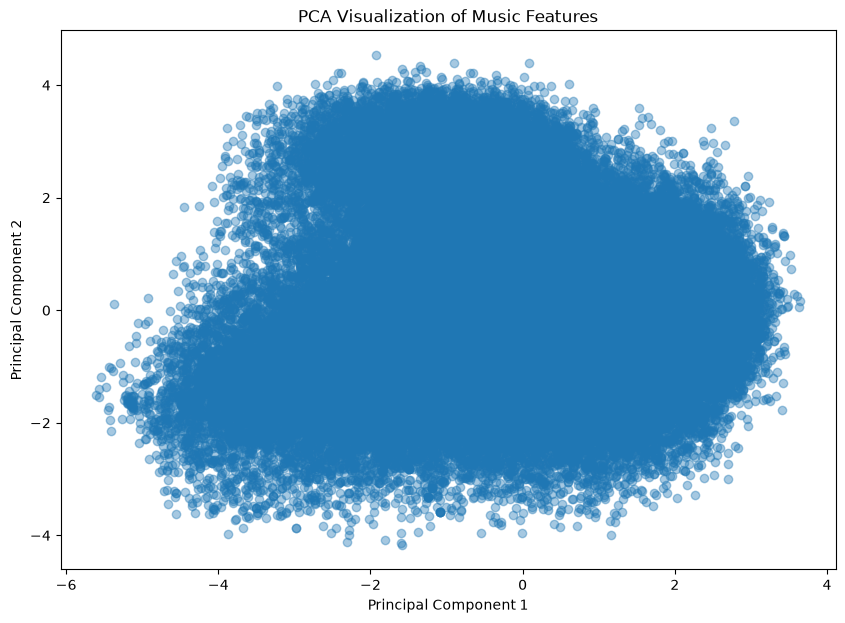

In [63]:
plt.figure(figsize=(10,7))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.4
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Music Features")

plt.show()

# 4. Clustering Techniques

### ELBOW METHOD + SILHOUETTE SCORE

In [10]:
inertia = []
silhouette_scores = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)

    score = silhouette_score(
            X_scaled,
            labels
        )
    
    silhouette_scores.append(score)

print("\nInertia values:", dict(zip(K, inertia)))
print("Silhouette scores:", dict(zip(K, silhouette_scores)))
    


Inertia values: {2: 778576.8014573371, 3: 656633.1807993986, 4: 607359.3484592799, 5: 565164.0685334008, 6: 534048.3891972245, 7: 511519.9613228998, 8: 493113.04355396505, 9: 476062.6098727998, 10: 460022.5135419939}
Silhouette scores: {2: 0.18368388697490645, 3: 0.20857289096438097, 4: 0.16261800777428972, 5: 0.1744708909011513, 6: 0.159205410306091, 7: 0.15209810870193477, 8: 0.15300752058481584, 9: 0.15042025800997022, 10: 0.1459845442943096}


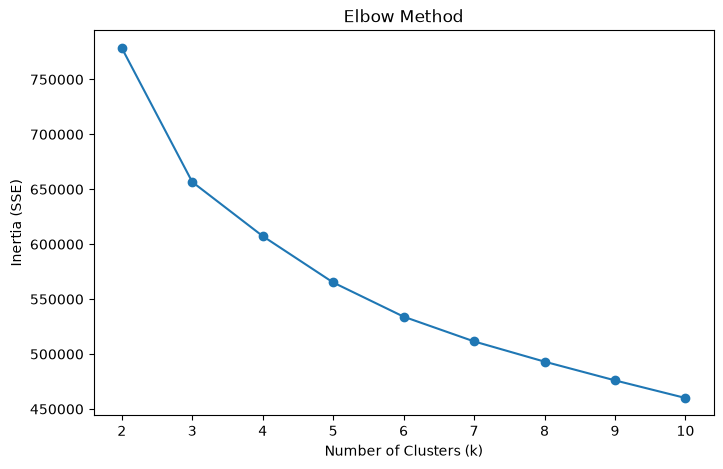

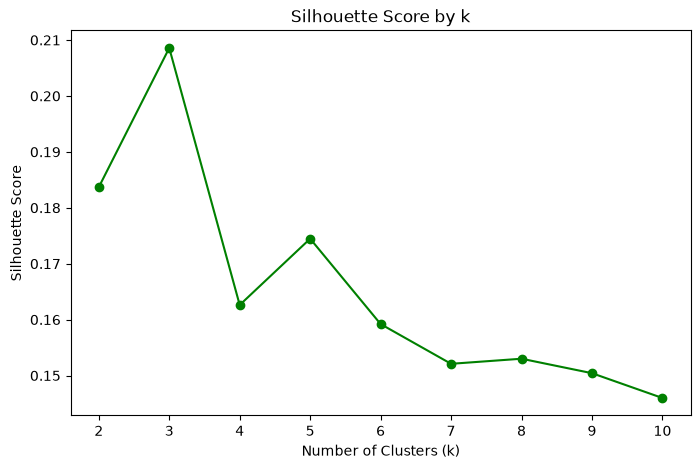

In [11]:
# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(list(K), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method")
# plt.savefig("elbow_method.png")
plt.show()
plt.close()
 
# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(list(K), silhouette_scores, marker="o", color="green")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k")
# plt.savefig("silhouette_scores.png")
plt.show()
plt.close()

### KMeans Clustering

In [12]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

In [13]:
df['cluster'] = cluster_labels

In [14]:
df['cluster'].value_counts().sort_index()   

cluster
0    29862
1    48908
2    17067
Name: count, dtype: int64

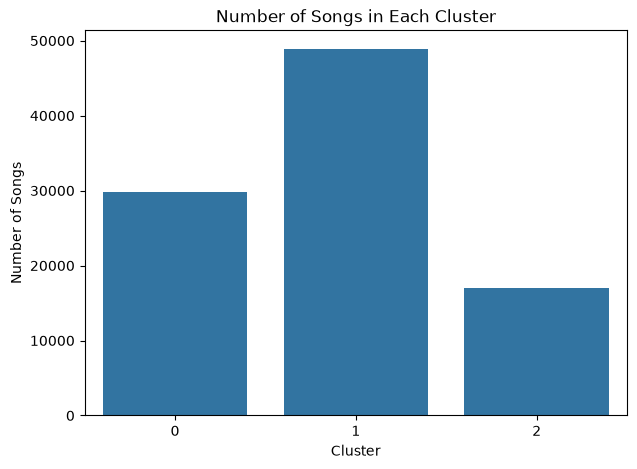

In [22]:

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='cluster'
)

plt.title("Number of Songs in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Songs")

plt.show()

# 5. Cluster Evaluation and Interpretation

### Silhouette Score

In [16]:

silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.20857289096438097


### Davies-Bouldin Index

In [17]:

db_score = davies_bouldin_score(
    X_scaled,
    cluster_labels
)

print("Davies-Bouldin Index:", db_score)

Davies-Bouldin Index: 1.636849315262605


### Inertia

In [18]:
print("Inertia:", kmeans.inertia_)

Inertia: 656633.1807993986


### Metrics

In [19]:
evaluation = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Inertia"
    ],
    "Value": [
        silhouette,
        db_score,
        kmeans.inertia_
    ]
})

print(evaluation)

                 Metric          Value
0      Silhouette Score       0.208573
1  Davies-Bouldin Index       1.636849
2               Inertia  656633.180799


### Cluster Profiling

In [75]:
cluster_profile = (
    df.groupby("cluster")[key_features]
      .mean()
      .round(2)
)

cluster_profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,0.48,0.32,-13.12,0.05,0.74,0.16,0.18,0.40,112.29,225421.40
1,0.62,0.70,-7.46,0.07,0.25,0.06,0.19,0.67,125.62,231182.71
2,0.67,0.47,-12.71,0.67,0.58,0.01,0.39,0.61,103.58,115195.06


In [59]:
cluster_names = {
    0: "Chill Acoustic & Instrumental",
    1: "Energetic Party & Pop Tracks",
    2: "Speech-Heavy / Spoken Tracks"
}

df["Cluster_Name"] = df["cluster"].map(cluster_names)

### 

Cluster_Name
Energetic Party & Pop Tracks     48908
Chill Acoustic & Instrumental    29862
Speech-Heavy / Spoken Tracks     17067
Name: count, dtype: int64


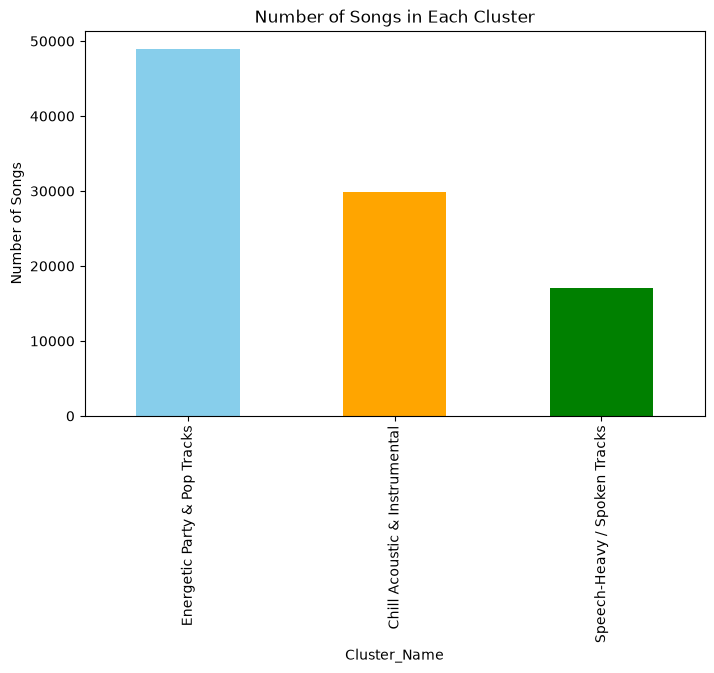

In [60]:
cluster_counts = df["Cluster_Name"].value_counts()

print(cluster_counts)

cluster_counts.plot(
    kind="bar",
    figsize=(8,5),
    color=["skyblue","orange","green"]
)

plt.title("Number of Songs in Each Cluster")
plt.ylabel("Number of Songs")
plt.show()

# 6. Visualization

### PCA 2D Scatter Plot

In [25]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

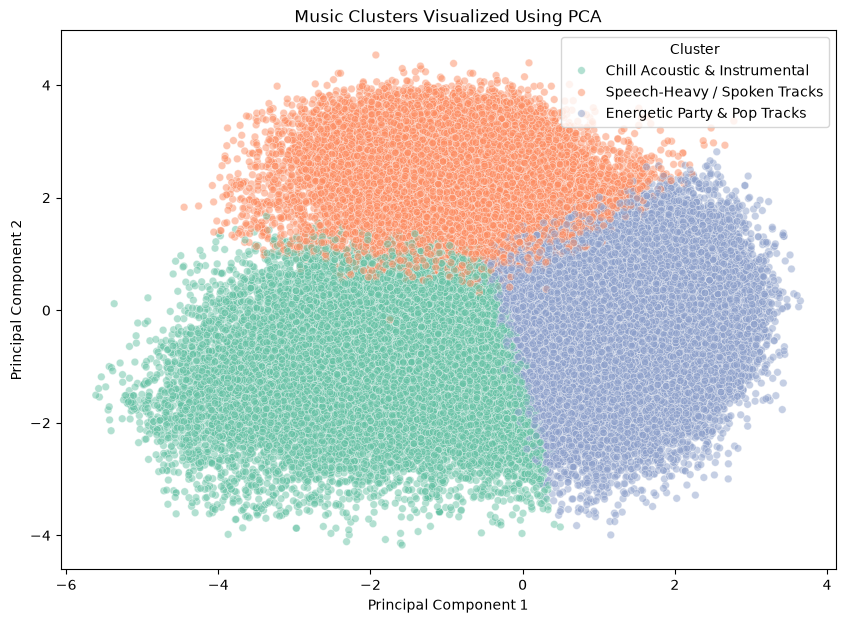

In [96]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="Cluster_Name",
    palette="Set2",
    alpha=0.5,
    s=30
)

plt.title("Music Clusters Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.savefig('../images/pca_clusters.png')
plt.show()

### Bar Chart

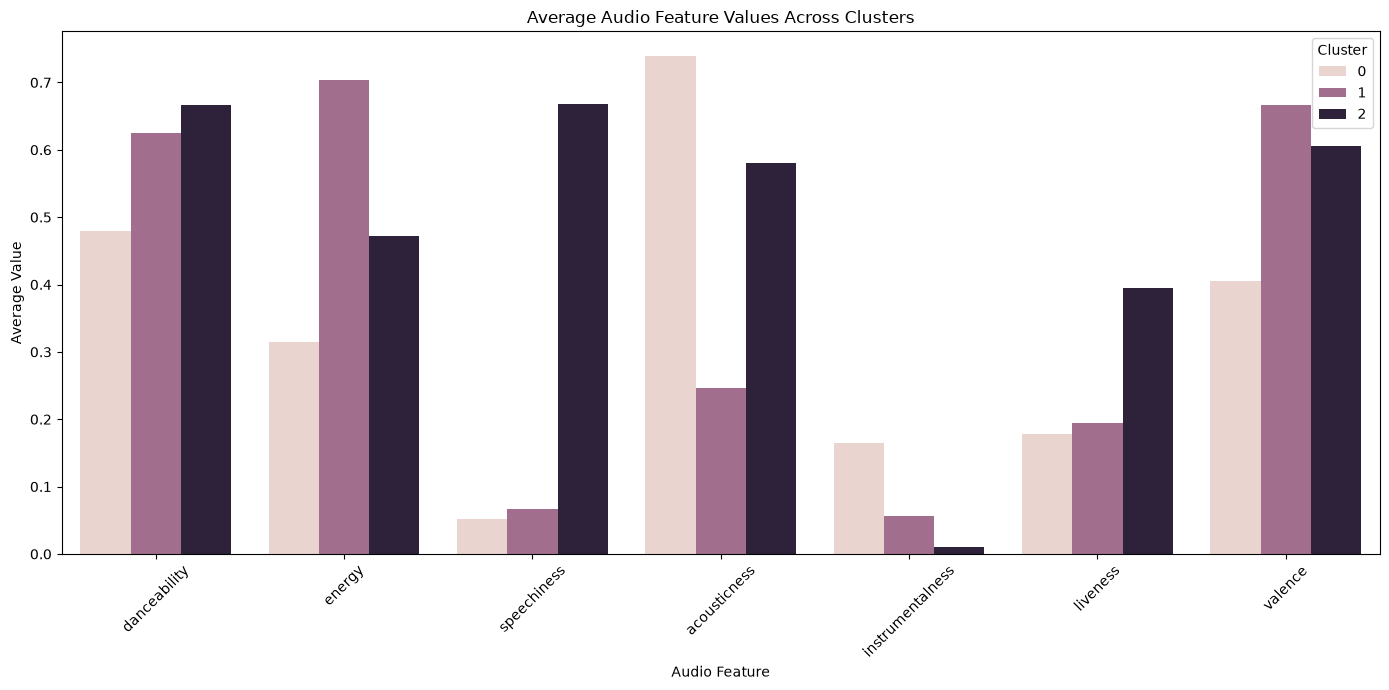

In [94]:
features_01 = [
    'danceability',
    'energy',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence'
]

cluster_profile = (
    df.groupby('cluster')[features_01]
      .mean()
      .reset_index()
)

profile_long = cluster_profile.melt(
    id_vars='cluster',
    var_name='Feature',
    value_name='Average Value'
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=profile_long,
    x='Feature',
    y='Average Value',
    hue='cluster'
)

plt.title('Average Audio Feature Values Across Clusters')
plt.xlabel('Audio Feature')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(title='Cluster')

plt.tight_layout()
plt.savefig('../images/average_audio_features.png')
plt.show()

### Heatmap

In [47]:
profile_scaled = pd.DataFrame(
    X_scaled,
    columns=key_features
)

profile_scaled["cluster"] = cluster_labels

scaled_cluster_profile = (
    profile_scaled
    .groupby("cluster")
    .mean()
)

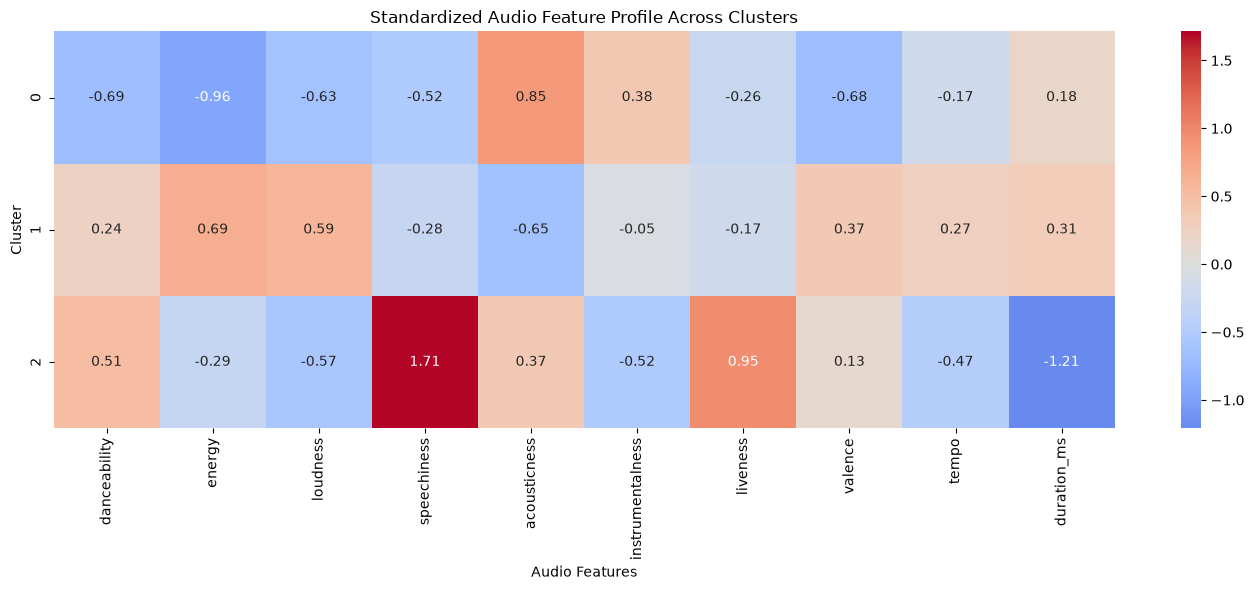

In [95]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    scaled_cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Audio Feature Profile Across Clusters")
plt.xlabel("Audio Features")
plt.ylabel("Cluster")

plt.tight_layout()
plt.savefig('../images/standardized_heatmap.png')
plt.show()

### Distribution plots

In [41]:
important_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "valence",
    "tempo"
]

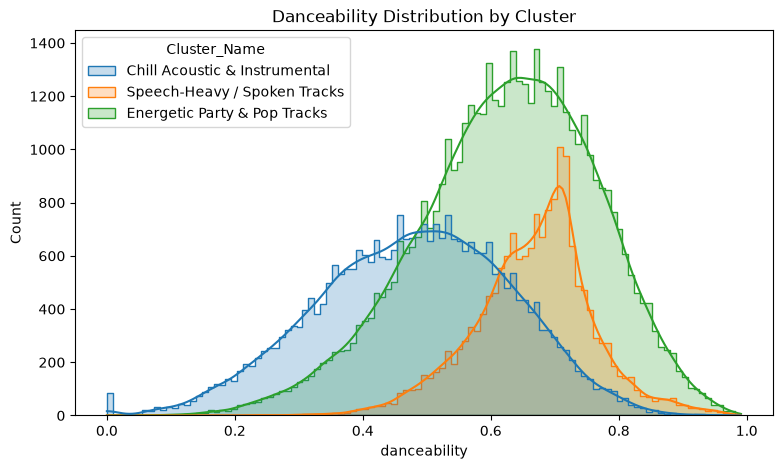

In [97]:
# Danceability
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="danceability",
    hue="Cluster_Name",
    kde=True,
    element="step"
)

plt.title("Danceability Distribution by Cluster")
plt.savefig('../images/danceability_distribution.png')
plt.show()

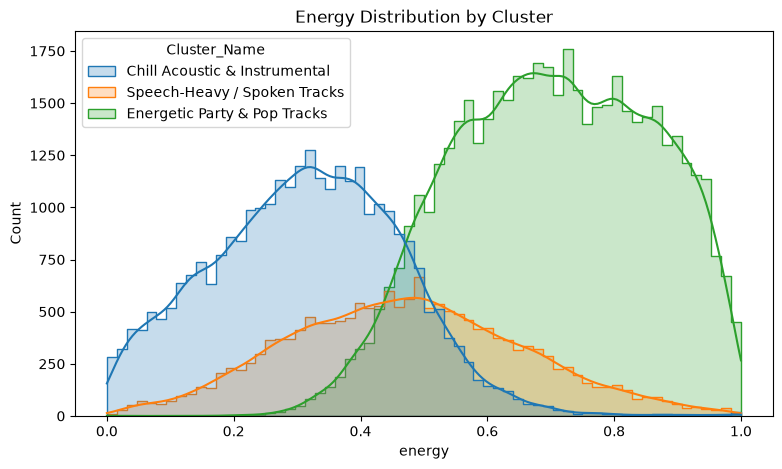

In [90]:
# Energy

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="energy",
    hue="Cluster_Name",
    kde=True,
    element="step"
)

plt.title("Energy Distribution by Cluster")
plt.savefig('../images/energy_distribution.png')
plt.show()

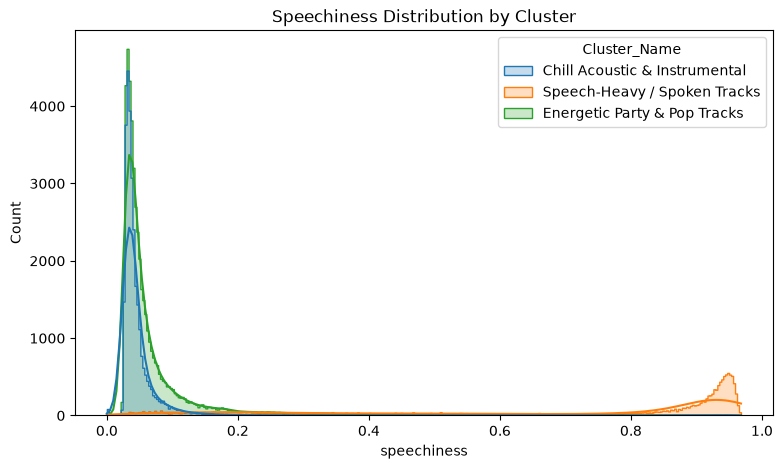

In [89]:
# Speechiness

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="speechiness",
    hue="Cluster_Name",
    kde=True,
    element="step"
)

plt.title("Speechiness Distribution by Cluster")
plt.savefig('../images/speech_distribution.png')
plt.show()

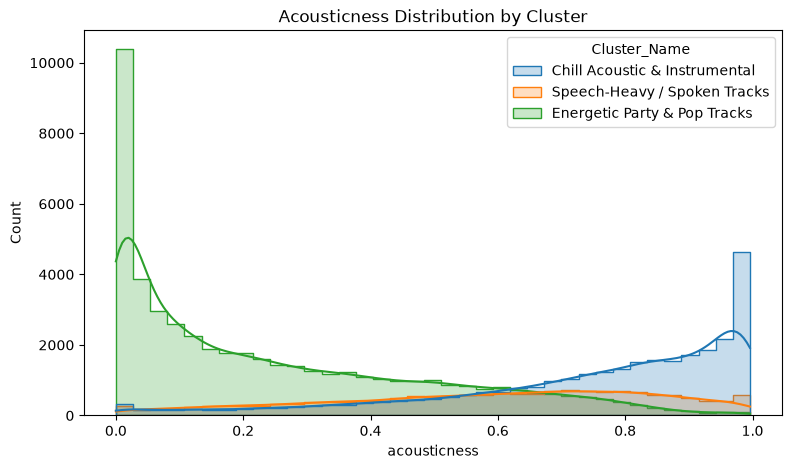

In [98]:
# Acousticness

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="acousticness",
    hue="Cluster_Name",
    kde=True,
    element="step"
)

plt.title("Acousticness Distribution by Cluster")
plt.savefig('../images/acousticness_distribution.png')
plt.show()

# 7. Final Analysis and Export

In [64]:
cluster_counts["Percentage"] = (
    cluster_counts["Song_Count"]
    / len(df) * 100
).round(2)

cluster_counts

,Cluster_Name,Song_Count,Percentage
0,Energetic Party & Pop Tracks,48908,51.03
1,Chill Acoustic & Instrumental,29862,31.16
2,Speech-Heavy / Spoken Tracks,17067,17.81


In [ ]:
original_df["cluster"] = df["cluster"].values
original_df["Cluster_Name"] = df["Cluster_Name"].values

In [69]:
final_df = original_df.copy()
for cluster in sorted(original_df["cluster"].unique()):

    cluster_name = final_df.loc[
        final_df["cluster"] == cluster,
        "Cluster_Name"
    ].iloc[0]

    print("\n" + "=" * 60)
    print(cluster_name)
    print("=" * 60)

    top_tracks = (
        final_df[final_df["cluster"] == cluster]
        .sort_values("popularity_songs", ascending=False)
        [["name_song", "name_artists", "popularity_songs"]]
        .head(10)
    )

    display(top_tracks)


Chill Acoustic & Instrumental


,name_song,name_artists,popularity_songs
35233,Arcade,Duncan Laurence,89
35436,Put Your Records On,Ritt Momney,87
35234,Arcade,Duncan Laurence,83
34858,Hold On,Chord Overstreet,83
35505,Control,Zoe Wees,80
34884,Beautiful Crazy,Luke Combs,80
34886,Better Together,Luke Combs,79
35566,Blue Jeans,GANGGA,79
35303,YKWIM?,Yot Club,79
35304,Ruthless (Nice Guys Always Finish Last),MarMar Oso,79



Energetic Party & Pop Tracks


,name_song,name_artists,popularity_songs
35665,Astronaut In The Ocean,Masked Wolf,98
35398,WITHOUT YOU,The Kid LAROI,94
35422,Hecha Pa' Mi,Boza,92
35532,911,Sech,91
35434,Goosebumps,HVME,89
35432,Whoopty,CJ,89
35668,Tapão Na Raba,Raí Saia Rodada,87
35506,Girls Like Us,Zoe Wees,86
35239,Dior,Pop Smoke,86
35437,Coração Na Cama,Hugo & Guilherme,86



Speech-Heavy / Spoken Tracks


,name_song,name_artists,popularity_songs
35241,What You Know Bout Love,Pop Smoke,91
35287,RAPSTAR,Polo G,89
35284,Martin & Gina,Polo G,88
35462,Dancing in My Room,347aidan,85
35463,ROLLIN N CONTROLLIN FREESTYLE,DUSTY LOCANE,83
35243,Element,Pop Smoke,82
35477,Deep End,Fousheé,82
35281,Through Da Storm,Polo G,80
34650,Go Fuck Yourself,Two Feet,80
32852,Verbatim,Mother Mother,80


In [70]:
final_df.shape

(95837, 25)

In [74]:
final_df.to_csv(
    "..\data\Amazon_Music_Clustered_Final.csv",
    index=False
)